In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy.stats import skew

np.random.seed(42)

In [2]:
# -------------------------------------------
# Homework 9 
# -------------------------------------------

# -------------------------------------------
# Homework 9: Reflection 1 - Heteroskadicity 
# -------------------------------------------

# Define the heteroskadicity data generation process (DGP)
# Generate many completely new datasets

def simulate_heteroskedastic(n=500):
    X = np.random.normal(0, 1, n)

    # Error SD grows as the absolute value of X increases
    error_sd = 1 + 2*np.abs(X)
    error = np.random.normal(0, error_sd, n)

    Y = 2*X + error

    return Y, X


In [3]:
# Estimate the true coefficient variability
# This is the empirical or “true” sampling standard deviation under the DGP

np.random.seed(42)

n_simulations = 5000
simulated_coefficients = []

for i in range(n_simulations):
    Y, X = simulate_heteroskedastic(n=500)

    X_model = sm.add_constant(X)
    model = sm.OLS(Y, X_model).fit()

    simulated_coefficients.append(model.params[1])

simulation_sd = np.std(simulated_coefficients, ddof=1)

print("Full simulation SD:", simulation_sd)

Full simulation SD: 0.1940766331091213


In [4]:
# Compare conventional and robust standard errors

Y, X = simulate_heteroskedastic(n=500)
X_model = sm.add_constant(X)

ordinary_model = sm.OLS(Y, X_model).fit()
robust_model = ordinary_model.get_robustcov_results(cov_type="HC3")

print("Estimated coefficient:", ordinary_model.params[1])
print("Full simulation SD:", simulation_sd)
print("Conventional OLS SE:", ordinary_model.bse[1])
print("HC3 robust SE:", robust_model.bse[1])

Estimated coefficient: 1.7758851286929094
Full simulation SD: 0.1940766331091213
Conventional OLS SE: 0.1384562326389495
HC3 robust SE: 0.239809780669609


The conventional OLS standard error assumes constant error variance. Because that assumption is violated, it will generally underestimate or otherwise incorrectly estimate the coefficient’s variability.

The HC3 robust standard error allows the errors to have different variances, so it should be closer to the full-simulation standard deviation.

In [5]:
# -------------------------------------------
# Homework 9: Reflection 2 - Highly correlated or non-independent errors 
# -------------------------------------------

# Define the correlated error DGP

def simulate_correlated_errors(n=500, rho=0.95):
    X = np.zeros(n)
    error = np.zeros(n)

    x_shocks = np.random.normal(0, 1, n)
    error_shocks = np.random.normal(0, 1, n)

    for t in range(1, n):
        # Persistent predictor
        X[t] = 0.8*X[t-1] + x_shocks[t]

        # Highly correlated errors
        error[t] = rho*error[t-1] + error_shocks[t]

    Y = 2*X + error

    return Y, X

In [6]:
# Estimate variability using full simulation

np.random.seed(42)

n_simulations = 5000
correlated_coefficients = []

for i in range(n_simulations):
    Y, X = simulate_correlated_errors(n=500, rho=0.95)

    X_model = sm.add_constant(X)
    model = sm.OLS(Y, X_model).fit()

    correlated_coefficients.append(model.params[1])

correlated_simulation_sd = np.std(
    correlated_coefficients,
    ddof=1
)

print("Full simulation SD:", correlated_simulation_sd)

Full simulation SD: 0.21858056565934542


In [7]:
# Compare conventional OLS and HAC standard errors

Y, X = simulate_correlated_errors(n=500, rho=0.95)
X_model = sm.add_constant(X)

ordinary_model = sm.OLS(Y, X_model).fit()

hac_model = ordinary_model.get_robustcov_results(
    cov_type="HAC",
    maxlags=10
)

print("Estimated coefficient:", ordinary_model.params[1])
print("Full simulation SD:", correlated_simulation_sd)
print("Conventional OLS SE:", ordinary_model.bse[1])
print("HAC robust SE:", hac_model.bse[1])

Estimated coefficient: 1.5326237731517356
Full simulation SD: 0.21858056565934542
Conventional OLS SE: 0.07424509014812235
HAC robust SE: 0.13679951656884365


The conventional OLS standard error treats all observations as independent, which is incorrect here. The HAC standard error accounts for dependence across nearby observations.

In [8]:
# Ordinary bootstrap comparison 

def ordinary_bootstrap_se(Y, X, n_bootstrap=2000):
    n = len(Y)
    bootstrap_coefficients = []

    for i in range(n_bootstrap):
        indices = np.random.choice(
            np.arange(n),
            size=n,
            replace=True
        )

        Y_boot = Y[indices]
        X_boot = X[indices]

        X_boot_model = sm.add_constant(X_boot)
        boot_model = sm.OLS(Y_boot, X_boot_model).fit()

        bootstrap_coefficients.append(boot_model.params[1])

    return np.std(bootstrap_coefficients, ddof=1)

In [9]:
# Run it on one dataset 

bootstrap_se = ordinary_bootstrap_se(
    Y,
    X,
    n_bootstrap=2000
)

print("Full simulation SD:", correlated_simulation_sd)
print("Conventional OLS SE:", ordinary_model.bse[1])
print("HAC SE:", hac_model.bse[1])
print("Ordinary bootstrap SE:", bootstrap_se)

Full simulation SD: 0.21858056565934542
Conventional OLS SE: 0.07424509014812235
HAC SE: 0.13679951656884365
Ordinary bootstrap SE: 0.07060342016001378


Ordinary bootstraps can fail because the ordinary bootstrap resamples individual observations and rearranges their order. That destroys the correlation between neighboring observations. It acts as if all rows were independent, so its estimated standard error may be too small.

In [10]:
# Block Boostrap

def block_bootstrap_se(
    Y,
    X,
    block_size=25,
    n_bootstrap=2000
):
    n = len(Y)
    bootstrap_coefficients = []

    for i in range(n_bootstrap):
        sampled_indices = []

        while len(sampled_indices) < n:
            start = np.random.randint(
                0,
                n - block_size + 1
            )

            block = np.arange(
                start,
                start + block_size
            )

            sampled_indices.extend(block)

        sampled_indices = np.array(sampled_indices[:n])

        Y_boot = Y[sampled_indices]
        X_boot = X[sampled_indices]

        X_boot_model = sm.add_constant(X_boot)
        boot_model = sm.OLS(Y_boot, X_boot_model).fit()

        bootstrap_coefficients.append(boot_model.params[1])

    return np.std(bootstrap_coefficients, ddof=1)

In [11]:
# Run the comparison

block_bootstrap_result = block_bootstrap_se(
    Y,
    X,
    block_size=25,
    n_bootstrap=2000
)

print("Full simulation SD:", correlated_simulation_sd)
print("Conventional OLS SE:", ordinary_model.bse[1])
print("HAC SE:", hac_model.bse[1])
print("Ordinary bootstrap SE:", bootstrap_se)
print("Block bootstrap SE:", block_bootstrap_result)

Full simulation SD: 0.21858056565934542
Conventional OLS SE: 0.07424509014812235
HAC SE: 0.13679951656884365
Ordinary bootstrap SE: 0.07060342016001378
Block bootstrap SE: 0.14014480755008984


In [12]:
# -------------------------------------------
# Homework 11 
# -------------------------------------------

# -------------------------------------------
# Homework 11: Reflection 1
# -------------------------------------------

# Create Simulated Dataset

np.random.seed(42)

# Time variable
t = np.arange(0, 100)

# Event happens at t = 50
event_time = 50

# Indicator for observations after event
event = (t >= event_time).astype(int)

# Time relative to event
post_time = np.maximum(t - event_time, 0)

# Generate outcome
y = (
    10
    + 0.2 * t
    + 0.005 * t**2
    + 5 * event
    + 0.3 * post_time
    + 0.01 * post_time**2
    + np.random.normal(0, 1, len(t))
)

df = pd.DataFrame({
    "time": t,
    "event": event,
    "post_time": post_time,
    "y": y
})

df.head()

,time,event,post_time,y
0,0,0,0,10.496714
1,1,0,0,10.066736
2,2,0,0,11.067689
3,3,0,0,12.168030
4,4,0,0,10.645847


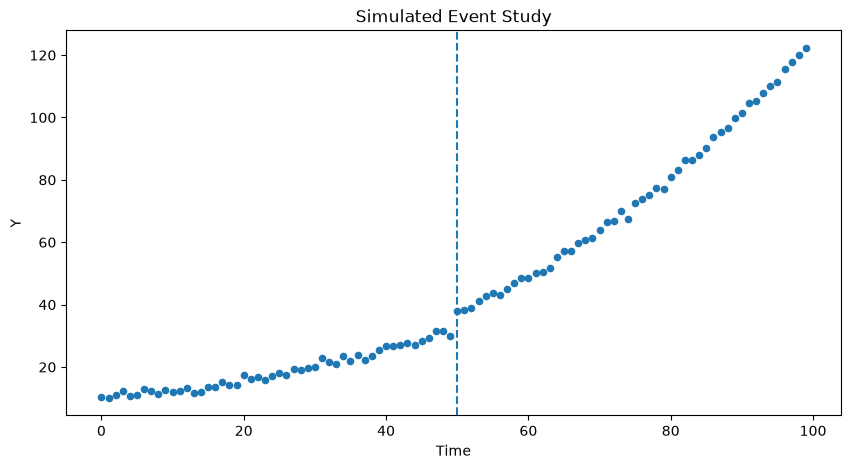

In [13]:
# Plot the Data

plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["y"], s=20)
plt.axvline(event_time, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Simulated Event Study")
plt.show()

In [14]:
# Model 1A: Use Only the Value Change

df["time_sq"] = df["time"] ** 2

model_value = smf.ols(
    "y ~ time + time_sq + event",
    data=df
).fit()

print(model_value.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.101e+04
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          4.31e-135
Time:                        15:06:35   Log-Likelihood:                -167.80
No. Observations:                 100   AIC:                             343.6
Df Residuals:                      96   BIC:                             354.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.9208      0.410     31.549      0.0

In [15]:
# Model 1B: Include value, derivative, and second derivative

# Create the squared post-event term
df["post_time_sq"] = df["post_time"] ** 2

# Estimate 
model_full = smf.ols(
    "y ~ time + time_sq + event + post_time + post_time_sq",
    data=df
).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.698e+04
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          1.03e-146
Time:                        15:06:36   Log-Likelihood:                -128.75
No. Observations:                 100   AIC:                             269.5
Df Residuals:                      94   BIC:                             285.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.4141      0.369     28.236   

In [16]:
# Compare the Models

print("Value-only model")
print("R-squared:", model_value.rsquared)
print("AIC:", model_value.aic)
print("BIC:", model_value.bic)

print("\nFull model")
print("R-squared:", model_full.rsquared)
print("AIC:", model_full.aic)
print("BIC:", model_full.bic)

Value-only model
R-squared: 0.9984792899590288
AIC: 343.59775314285093
BIC: 354.0184338868033

Full model
R-squared: 0.9993036449325126
AIC: 269.4904579128382
BIC: 285.12147902876677


In [17]:
# -------------------------------------------
# Homework 11: Reflection 2
# -------------------------------------------


# Generate the data
np.random.seed(42)

times = np.arange(0, 100)

groups = {
    "A": 10,
    "B": 20,
    "C": 30
}

rows = []

for group, baseline in groups.items():

    for t in times:

        event = int(t >= 50)

        y = (
            baseline
            + 0.2 * t
            + 5 * event
            + np.random.normal(0, 1)
        )

        rows.append({
            "group": group,
            "time": t,
            "event": event,
            "y": y
        })

df_groups = pd.DataFrame(rows)

df_groups.head()

,group,time,event,y
0,A,0,0,10.496714
1,A,1,0,10.061736
2,A,2,0,11.047689
3,A,3,0,12.123030
4,A,4,0,10.565847


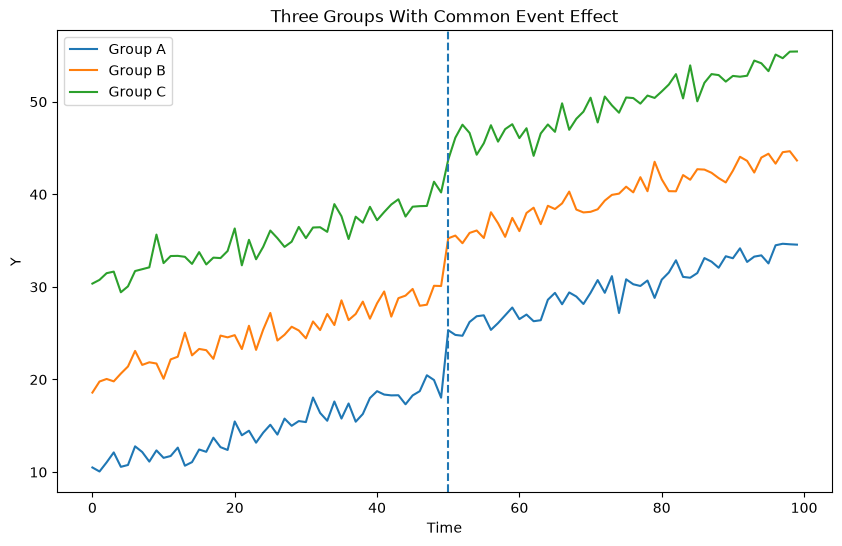

In [18]:
# Plot the groups

plt.figure(figsize=(10, 6))

for group in df_groups["group"].unique():
    temp = df_groups[df_groups["group"] == group]

    plt.plot(
        temp["time"],
        temp["y"],
        label=f"Group {group}"
    )

plt.axvline(50, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Y")
plt.title("Three Groups With Common Event Effect")
plt.legend()
plt.show()

In [19]:
# Add group fixed effects

fixed_effect_model = smf.ols(
    "y ~ time + event + C(group)",
    data=df_groups
).fit()

print(fixed_effect_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 1.026e+04
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:06:37   Log-Likelihood:                -418.17
No. Observations:                 300   AIC:                             846.3
Df Residuals:                     295   BIC:                             864.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        10.0162      0.149     67.238

In [20]:
# -------------------------------------------
# Homework 12: Reflection 1
# -------------------------------------------

np.random.seed(42)

times = np.arange(0, 100)
event_time = 50

rows = []

for group in ["Control", "Treatment"]:
    for t in times:
        
        post = int(t >= event_time)
        treated = int(group == "Treatment")
        
        if group == "Control":
            # Control grows at 0.2 per period
            y = 10 + 0.2 * t
            
        else:
            # Treatment already grows faster BEFORE treatment
            y = 10 + 0.35 * t
            
            # True treatment effect after event = +5
            if post:
                y += 5
        
        # Add noise
        y += np.random.normal(0, 1)
        
        rows.append({
            "time": t,
            "group": group,
            "treated": treated,
            "post": post,
            "y": y
        })

df = pd.DataFrame(rows)

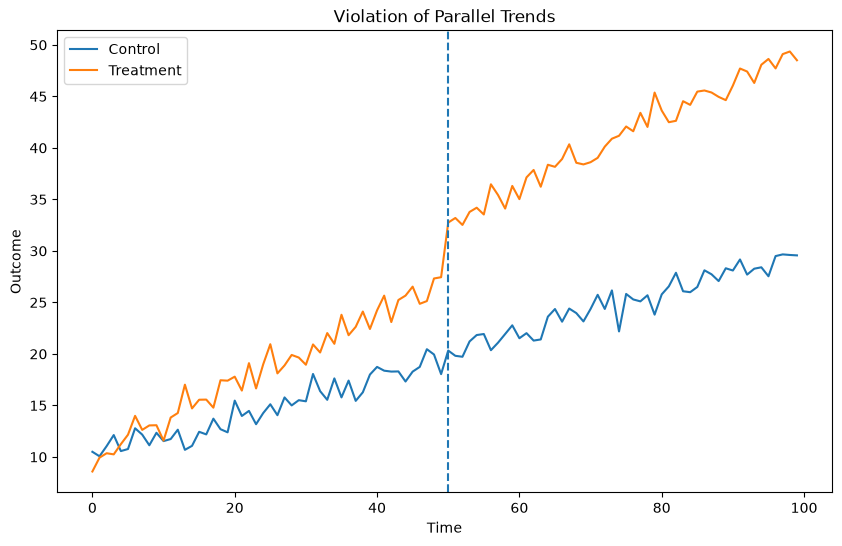

In [21]:
# Plot the data 

plt.figure(figsize=(10, 6))

for group in df["group"].unique():
    temp = df[df["group"] == group]
    plt.plot(temp["time"], temp["y"], label=group)

plt.axvline(event_time, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Outcome")
plt.title("Violation of Parallel Trends")
plt.legend()
plt.show()

In [22]:
# Create DID interaction term

df["did"] = df["treated"] * df["post"]

In [23]:
# Estimate a standard DID model 

did_model = smf.ols(
    "y ~ treated + post + did",
    data=df
).fit()

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     395.3
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           7.72e-83
Time:                        15:06:39   Log-Likelihood:                -566.60
No. Observations:                 200   AIC:                             1141.
Df Residuals:                     196   BIC:                             1154.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.6745      0.588     24.977      0.0

In [24]:
# Create a simplified demonstration to better visualize effects 

np.random.seed(42)

times = np.arange(0, 10)
event_time = 5

rows = []

for group in ["Control", "Treatment"]:
    for t in times:
        
        treated = int(group == "Treatment")
        post = int(t >= event_time)
        
        if group == "Control":
            y = 10 + 1 * t
        else:
            # Already growing faster
            y = 10 + 2 * t
            
            # True event effect
            if post:
                y += 5
        
        y += np.random.normal(0, 0.3)
        
        rows.append({
            "time": t,
            "group": group,
            "treated": treated,
            "post": post,
            "y": y
        })

df = pd.DataFrame(rows)
df["did"] = df["treated"] * df["post"]

In [25]:
# Create model 

did_model = smf.ols(
    "y ~ treated + post + did",
    data=df
).fit()

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     48.09
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           3.14e-08
Time:                        15:06:40   Log-Likelihood:                -43.857
No. Observations:                  20   AIC:                             95.71
Df Residuals:                      16   BIC:                             99.70
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.1377      1.084     11.196      0.0

In [26]:
# Calculate the DiD manually 

means = df.groupby(["group", "post"])["y"].mean()
print(means)

control_pre = means["Control", 0]
control_post = means["Control", 1]

treat_pre = means["Treatment", 0]
treat_post = means["Treatment", 1]

did_estimate = (
    (treat_post - treat_pre)
    - (control_post - control_pre)
)

print("DiD estimate:", did_estimate)
print("True treatment effect:", 5)
print("Bias:", did_estimate - 5)

group      post
Control    0       12.137701
           1       17.131136
Treatment  0       13.740477
           1       28.785128
Name: y, dtype: float64
DiD estimate: 10.051216167064844
True treatment effect: 5
Bias: 5.051216167064844
